# Autoencoder with ACCESS-OM2

Autoencoder with ACCESS-OM2 Ocean Heat Content Data

This notebook trains an autoencoder on ocean heat content and surface heat flux data from the ACCESS-OM2 model using partial convolutions to handle land-masked regions.

In [3]:
# System and path handling
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
import xarray as xr

# PyEarthTools pipeline
import pyearthtools.data as petdata
from pyearthtools.data.transforms import TransformCollection
import pyearthtools.pipeline as petpipe
import pyearthtools.data.archive as arch

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Visualization
import matplotlib.pyplot as plt

# Configure device and random seed
torch.manual_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Source data and code directories
userbase = "/g/data/nm47/txs156/"
repobase = "/home/561/rmh561/ML/OM2-emulator/"

# Add the src directory to the Python path (relative to notebook location)
src_path = Path(repobase) / "src"
sys.path.insert(0, str(src_path))

# Import the ACCESS_OHC data accessor from om2_data_utils module
from om2_data_utils import ACCESS_OHC

## Setup PyEarthTools data accessor and pipeline

In [8]:
# Setup the data accessor and pipeline
ACCESS_OHC_accessor = ACCESS_OHC(
    ["area_t", "ocean_heat_content_2d", "total_surface_heat_flx"],
    root=userbase + "OM2-emulator/data/",
)

# Full access pipeline:
full = petpipe.Pipeline(
    ACCESS_OHC_accessor,
    petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
    petdata.transforms.variables.Drop(['area_t']),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('2000-06', '2001-01', interval='1 month')
)

ipipe = iter(full)  # Make an iterator to walk the time period
full.exceptions_to_ignore
n = next(ipipe)

In [10]:
# Quick check on just the raw data to see we're accessing things correctly:
testpipe = petpipe.Pipeline(
    ACCESS_OHC_accessor,
    iterator=petpipe.iterators.DateRange('2000-01','2001-01', interval='1 month')
)
itest = iter(testpipe)
test_sample = next(itest)
test_sample

<xarray.Dataset> Size: 2MB
Dimensions:                 (time: 1, latitude: 300, longitude: 360)
Coordinates:
  * longitude               (longitude) float64 3kB -279.5 -278.5 ... 78.5 79.5
  * latitude                (latitude) float64 2kB -77.88 -77.63 ... 89.32 89.77
    geolat_t                (latitude, longitude) float32 432kB ...
    geolon_t                (latitude, longitude) float32 432kB ...
  * time                    (time) datetime64[ns] 8B 2000-01-14T12:00:00
Data variables:
    ocean_heat_content_2d   (time, latitude, longitude) float32 432kB ...
    total_surface_heat_flx  (time, latitude, longitude) float32 432kB ...
    area_t                  (latitude, longitude) float32 432kB ...

In [5]:
# Define partial convolution operator:

class PartialConv2d(nn.Module):
    """
    Mask-aware (partial) 2D convolution layer.

    This layer implements a simplified version of the partial convolution
    described in:

        Liu et al. (2018)
        "Image Inpainting for Irregular Holes Using Partial Convolutions"

    The key idea is that convolution is performed using only valid pixels
    defined by a binary mask.

    In this implementation:
        mask = 1  -> valid pixel (ocean)
        mask = 0  -> invalid pixel (land)

    The layer performs three operations:

    1. Mask the input
       x_masked = x * mask

    2. Apply a standard convolution
       out = Conv2D(x_masked)

    3. Renormalize by the number of valid pixels contributing to each
       convolution window.

       If N pixels were valid in a KxK window, the output is multiplied by:

            kernel_area / N

       This prevents the convolution amplitude from shrinking near masked
       regions (coastlines).

    4. Update the mask

       The new mask is defined as:

            new_mask = 1 if any valid pixel existed in the window
                     = 0 otherwise

       This allows the mask to propagate through the network.

    Parameters
    ----------
    in_ch : int
        Number of input channels.

    out_ch : int
        Number of output channels.

    kernel_size : int
        Size of convolution kernel.

    stride : int
        Convolution stride. When stride > 1 the output spatial dimensions
        shrink, which allows use in encoder networks.

    padding : int
        Padding size.

    Notes
    -----
    * padding_mode='replicate' is used to avoid artificial zeros near the
      boundary.
    * The mask convolution is fixed (all weights = 1) and has no gradients.
    """

    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()

        self.conv = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            padding_mode="replicate",
        )

        # convolution used only to count valid pixels
        self.mask_conv = nn.Conv2d(
            1,
            1,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            padding_mode="replicate",
            bias=False,
        )

        self.mask_conv.weight.data[:] = 1.0
        self.mask_conv.requires_grad_(False)

        self.kernel_area = kernel_size * kernel_size
        self.eps = 1e-6

    def forward(self, x, mask):
        """
        Forward pass.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape:

                (batch, channels, height, width)

        mask : torch.Tensor
            Binary mask tensor:

                (batch, 1, height, width)

            1 = valid pixel
            0 = invalid pixel

        Returns
        -------
        out : torch.Tensor
            Convolution output

                (batch, out_channels, new_height, new_width)

        new_mask : torch.Tensor
            Updated mask

                (batch, 1, new_height, new_width)
        """

        # apply mask to input
        x_masked = x * mask

        # convolution
        out = self.conv(x_masked)

        # count valid pixels in each convolution window
        with torch.no_grad():
            mask_sum = self.mask_conv(mask)

        # renormalize output
        out = torch.where(
            mask_sum > 0,
            out * (self.kernel_area / (mask_sum + self.eps)),
            torch.zeros_like(out),
        )

        # updated mask
        new_mask = (mask_sum > 0).float()

        return out, new_mask

In [6]:
# Compute time-independent mask from the sample:
mask_xr = xr.where(np.isnan(merged_sample.total_surface_heat_flx.isel(time=0,drop=True)),0,1).rename('ocean_mask')

Output shape: torch.Size([1, 1, 150, 180])
Mask shape: torch.Size([1, 1, 150, 180])
Original valid fraction: 0.6463796496391296
New valid fraction: 0.6898888945579529


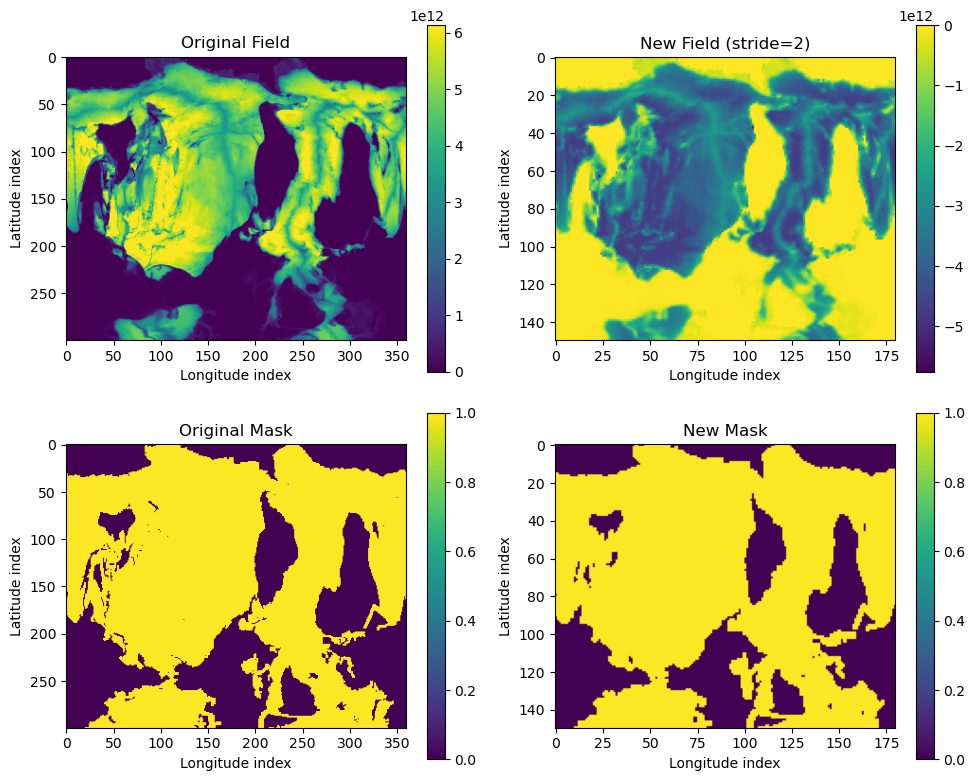

In [12]:
# Test Partial Convolution:
# remove time dimension
data_np = merged_sample.ocean_heat_content_2d.isel(time=0).values
mask_np = mask_xr.values

# convert to tensors
x = torch.tensor(data_np, dtype=torch.float32)
mask = torch.tensor(mask_np, dtype=torch.float32)

# add batch + channel dimensions
x = x.unsqueeze(0).unsqueeze(0)
mask = mask.unsqueeze(0).unsqueeze(0)

# Do an example convolution:
layer = PartialConv2d(in_ch=1,out_ch=1,kernel_size=3,stride=2,padding=1)

out, new_mask = layer(x, mask)

print("Output shape:", out.shape)
print("Mask shape:", new_mask.shape)

out_np = out.detach().squeeze().numpy()
mask_np2 = new_mask.detach().squeeze().numpy()


# Convert tensors → numpy
orig_field = x.detach().squeeze().numpy()
orig_mask  = mask.detach().squeeze().numpy()

new_field = out.detach().squeeze().numpy()
new_mask  = new_mask.detach().squeeze().numpy()

# Fractions covered by ocean:
print("Original valid fraction:", orig_mask.mean().item())
print("New valid fraction:", new_mask.mean().item())

# Plot the results:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Original field
im0 = axes[0,0].imshow(orig_field)
axes[0,0].set_title("Original Field")
plt.colorbar(im0, ax=axes[0,0])

# Original mask
im1 = axes[1,0].imshow(orig_mask)
axes[1,0].set_title("Original Mask")
plt.colorbar(im1, ax=axes[1,0])

# New field
im2 = axes[0,1].imshow(new_field)
axes[0,1].set_title("New Field (stride=2)")
plt.colorbar(im2, ax=axes[0,1])

# New mask
im3 = axes[1,1].imshow(new_mask)
axes[1,1].set_title("New Mask")
plt.colorbar(im3, ax=axes[1,1])

for ax in axes.flat:
    ax.set_xlabel("Longitude index")
    ax.set_ylabel("Latitude index")

plt.tight_layout()
plt.show()


In [32]:
class AutoEncoder(nn.Module):

    def __init__(self,
                 input_channel_count=2,
                 output_channel_count=2):

        super(AutoEncoder, self).__init__()

        # ---------- Encoder ----------
        self.enc1 = PartialConv2d(input_channel_count, 16, kernel_size=4, stride=2, padding=1)
        self.enc2 = PartialConv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = PartialConv2d(32, 64, kernel_size=7, stride=1, padding=3)

        # ---------- Decoder ----------
        self.dec1 = PartialConv2d(64, 32, kernel_size=7, stride=1, padding=3)
        self.dec2 = PartialConv2d(32, 16, kernel_size=3, stride=1, padding=1)
        self.dec3 = PartialConv2d(16, output_channel_count, kernel_size=4, stride=1, padding=1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def encode(self, x, mask):
        # Encoder forward pass
        x, mask = self.enc1(x, mask)
        x = self.relu(x)
        x, mask = self.enc2(x, mask)
        x = self.relu(x)
        x, mask = self.enc3(x, mask)
        x = self.relu(x)
        return x, mask
    
    def forward(self, x, mask):

        # ---------- Encoder ----------
        x, mask = self.enc1(x, mask)
        x = self.relu(x)

        x, mask = self.enc2(x, mask)
        x = self.relu(x)

        x, mask = self.enc3(x, mask)
        latent = self.relu(x)

        # ---------- Decoder ----------

        # upsample 1
        x = F.interpolate(latent, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec1(x, mask)
        x = self.relu(x)

        # upsample 2
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec2(x, mask)
        x = self.relu(x)

        # final conv
        x, mask = self.dec3(x, mask)

        reconstructed = self.sigmoid(x)

        return reconstructed

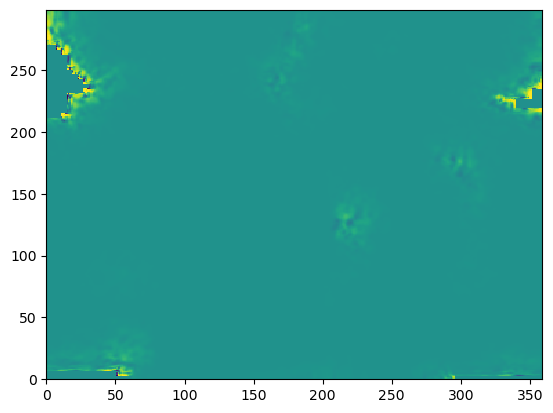

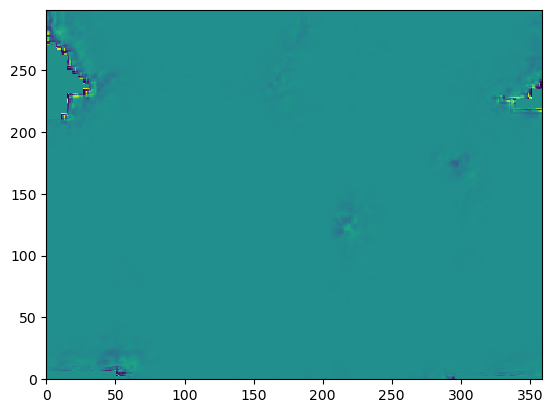

In [33]:
# Initialize model and move to device
model = AutoEncoder(input_channel_count=n.shape[1], output_channel_count=n.shape[1]).to(device)

# Loss function and optimizer
criterion = nn.L1Loss()
# criterion = nn.KLDivLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Convert numpy -> tensor:
x = torch.from_numpy(n).float().to(device)

# Normalization ignoring NaNs:
mean = x.nanmean(dim=(0, 2, 3), keepdim=True)  # (1, C, 1, 1)
var = torch.nanmean((x - mean) ** 2, dim=(0, 2, 3), keepdim=True)
std = torch.sqrt(var + 1e-6)
x_norm = (x - mean) / (std + 1e-6)
x_norm = torch.nan_to_num(x_norm, nan=0.0)
x_in = x_norm

# Prepare mask:
mask = torch.tensor(mask_xr.values, dtype=torch.float32).unsqueeze(0).unsqueeze(0).float().to(device)

# This should make us a messy prediction from an untrained model in the dimension of the input
prediction = model(x_in, mask)

image_numpy_for_display = prediction.to('cpu').detach().numpy()
plt.pcolor(image_numpy_for_display[0][0])
plt.show()
plt.pcolor(image_numpy_for_display[0][1])
plt.show()

In [34]:
%%time

# 1000 samples is taking about 2 minutes
# It should be able to go much much much faster, but still we can test it and make progress
# Let's to 30 minutes of training, i.e. 15k samples

def train(debug=True, num_epochs=1, max_samples=10, print_per=20):
    # Training loop
    
    sample_ix = 0 
    
    
    for epoch in range(num_epochs):
        total_loss = 0    
        epoch_samples = 0
        ipipe = iter(full)  # Make an iterator to walk the time period
    
        while True:
            try:
                sample = next(ipipe)
            except StopIteration:
                break  # advance the epoch loop
            except:
                pass # some samples are just missing
    
            sample_ix += 1
            epoch_samples += 1
            if epoch_samples % print_per == 0:
                print(epoch_samples)
            
            if sample_ix > max_samples:
                break

            if debug:
                print(sample_ix)
    
            x = torch.from_numpy(sample).float().to(device)   
            mean = x.nanmean(dim=(0, 2, 3), keepdim=True)  # (1, C, 1, 1)
            var = torch.nanmean((x - mean) ** 2, dim=(0, 2, 3), keepdim=True)
            std = torch.sqrt(var + 1e-6)
            x_norm = (x - mean) / (std + 1e-6)
            x_norm = torch.nan_to_num(x_norm, nan=0.0)

            x_in = x_norm
                
            if debug:
                print("Input")
                print(x_in)
    
            optimizer.zero_grad()
    
            # Forward pass
            y = model(x_in, mask)

            # Ensure prediction and input match spatial dimensions
            H = min(y.shape[2], x_in.shape[2])
            W = min(y.shape[3], x_in.shape[3])
            
            y = y[:, :, :H, :W]
            x_in = x_in[:, :, :H, :W]
            mask_use = mask[:, :, :H, :W]
            
            if debug:
                print("prediction")
                print(y)
            
            diff = torch.abs(y - x_in)
            mask_broadcast = mask_use.expand_as(diff)
            loss = (diff * mask_broadcast).sum() / mask_broadcast.sum()
            
            if debug:
                print("loss")
                print(loss)
    
            # Backward pass and optimize        
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        # Print epoch statistics
        avg_loss = total_loss / epoch_samples
        print(f'Epoch [{epoch+1}/{epoch_samples}], Average Loss: {avg_loss:.4f}')
        epoch_samples = 0  # Reset for next epoch

train(debug=False, num_epochs=100, max_samples=15 * 1000, print_per = 500)

Epoch [1/7], Average Loss: 0.7573
Epoch [2/7], Average Loss: 0.7510
Epoch [3/7], Average Loss: 0.7344
Epoch [4/7], Average Loss: 0.7048
Epoch [5/7], Average Loss: 0.6719
Epoch [6/7], Average Loss: 0.6404
Epoch [7/7], Average Loss: 0.6083
Epoch [8/7], Average Loss: 0.5736
Epoch [9/7], Average Loss: 0.5480
Epoch [10/7], Average Loss: 0.5274
Epoch [11/7], Average Loss: 0.5101
Epoch [12/7], Average Loss: 0.4919
Epoch [13/7], Average Loss: 0.4836
Epoch [14/7], Average Loss: 0.4789
Epoch [15/7], Average Loss: 0.4757
Epoch [16/7], Average Loss: 0.4731
Epoch [17/7], Average Loss: 0.4705
Epoch [18/7], Average Loss: 0.4681
Epoch [19/7], Average Loss: 0.4663
Epoch [20/7], Average Loss: 0.4647
Epoch [21/7], Average Loss: 0.4631
Epoch [22/7], Average Loss: 0.4615
Epoch [23/7], Average Loss: 0.4601
Epoch [24/7], Average Loss: 0.4587
Epoch [25/7], Average Loss: 0.4573
Epoch [26/7], Average Loss: 0.4560
Epoch [27/7], Average Loss: 0.4549
Epoch [28/7], Average Loss: 0.4536
Epoch [29/7], Average Loss: 0

In [38]:
prediction = model(x_in, mask)

# Ensure prediction and input have the same spatial size
H = min(prediction.shape[2], x_in.shape[2])
W = min(prediction.shape[3], x_in.shape[3])

prediction_cropped = prediction[:, :, :H, :W]
x_norm_cropped = x_in[:, :, :H, :W]
std_cropped = std[:, :, :H, :W]
mean_cropped = mean[:, :, :H, :W]

# Convert back to physical units
prediction_phys = prediction_cropped[:, :x_norm.shape[1]] * (std_cropped + 1e-6) + mean_cropped
input_phys = x_norm_cropped[:, :x_norm.shape[1]] * (std_cropped + 1e-6) + mean_cropped

# Move to CPU for visualization
prediction_display = prediction_phys.detach().cpu().numpy()
input_display = input_phys.detach().cpu().numpy()

## Diagnostics

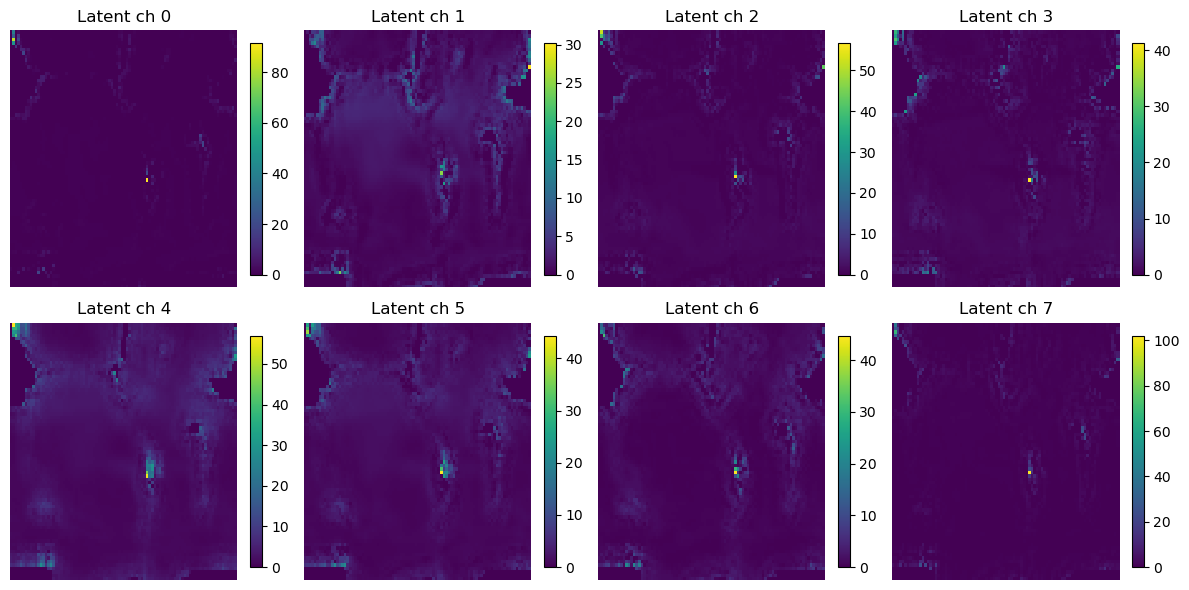

In [37]:
## Inspect Latent Space

latent, latent_mask = model.encode(x_in, mask)
z = latent[0].detach().cpu().numpy()  # (C_latent, H_latent, W_latent)

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axs.flat):
    if i < z.shape[0]:  # safety if latent has fewer channels
        im = ax.pcolor(z[i], cmap="viridis")
        ax.set_title(f"Latent ch {i}")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [40]:
## Plot errors

RMSE = []

ds = xr.open_dataset(userbase+"OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
area_t = ds.area_t.values.astype(np.float64)

# Broadcast mask to shape (H, W)
land_mask = np.isfinite(input_display[0,0]) & (area_t > 0)
area_weighted = area_t * land_mask

# Compute per-channel error
err1 = prediction_display[0,0] - input_display[0,0]
err2 = prediction_display[0,1] - input_display[0,1]

rmse1 = np.sqrt(np.nansum(err1**2 * area_weighted) / np.nansum(area_weighted))
rmse2 = np.sqrt(np.nansum(err2**2 * area_weighted) / np.nansum(area_weighted))

RMSE.append(rmse2)
RMSE.append(rmse1)

ValueError: operands could not be broadcast together with shapes (299,359) (300,360) 

In [41]:
print(np.nansum((prediction_display[0][1] - input_display[0][1])**2*land_aware_area_t))
print(np.nansum(land_aware_area_t))
print(np.nansum((prediction_display[0][1] - input_display[0][1])**2))

ValueError: operands could not be broadcast together with shapes (299,359) (300,360) 

ValueError: operands could not be broadcast together with shapes (299,359) (300,360) 

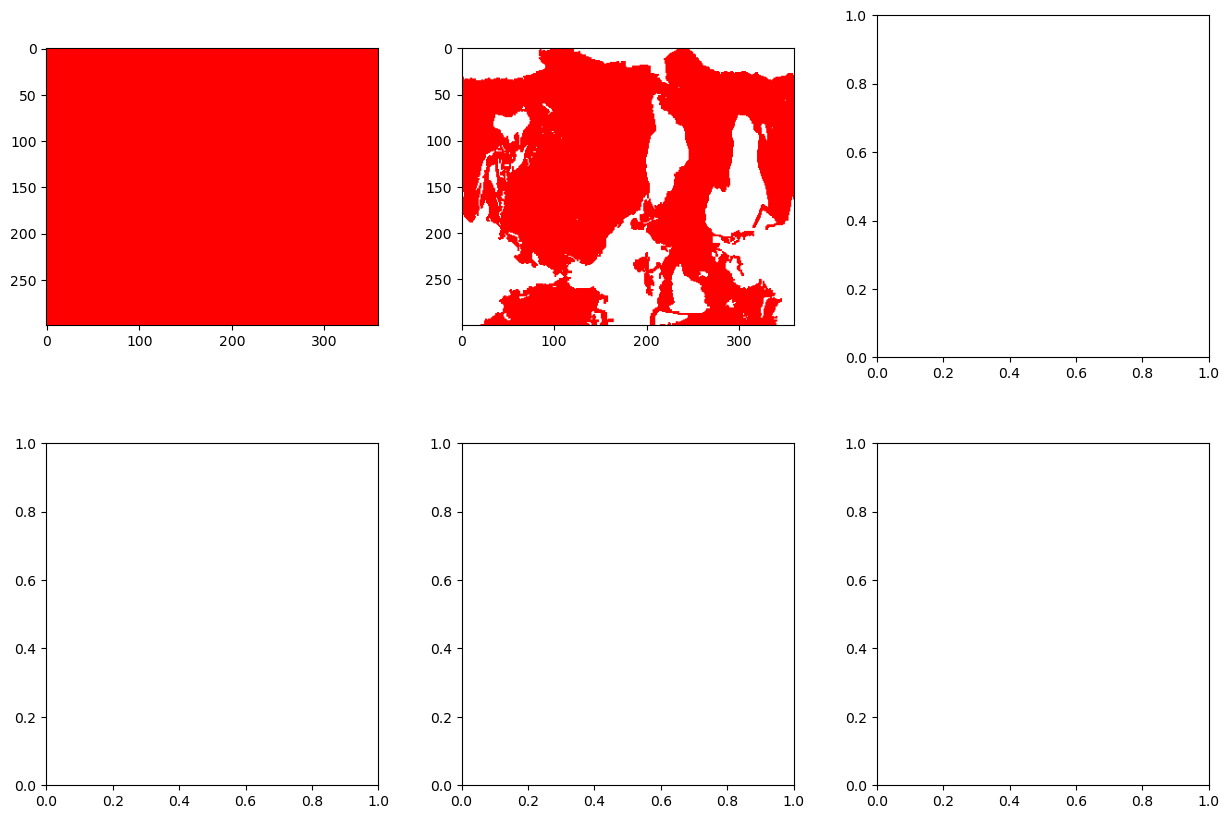

In [28]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(30*0.5, 20*0.5))
gs = fig.add_gridspec(2, 3, wspace=0.25, hspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# ---- Row 1: Heat Flux ----
im1 = ax1.imshow(
    prediction_display[0][1]*(30*24*3600),
    vmin=-1e8, vmax=1e8,
    cmap=plt.cm.bwr
)
ax2.imshow(
    input_display[0][1]*(30*24*3600),
    vmin=-1e8, vmax=1e8,
    cmap=plt.cm.bwr
)
im3 = ax3.imshow(
    prediction_display[0][1]*(30*24*3600) - input_display[0][1]*(30*24*3600),
    vmin=-1e8, vmax=1e8,
    cmap=plt.cm.bwr
)

for ax in (ax1, ax2, ax3):
    ax.invert_yaxis()

# ---- Row 2: OHC ----
im4 = ax4.imshow(
    prediction_display[0][0],
    vmin=-1e13, vmax=1e13,
    cmap=plt.cm.bwr
)
ax5.imshow(
    input_display[0][0],
    vmin=-1e13, vmax=1e13,
    cmap=plt.cm.bwr
)
im6 = ax6.imshow(
    prediction_display[0][0] - input_display[0][0],
    vmin=-1e13, vmax=1e13,
    cmap=plt.cm.bwr
)


for ax in (ax4, ax5, ax6):
    ax.invert_yaxis()

# ---- Titles ----
ax1.set_title("Prediction")
ax2.set_title("Actual")
ax3.set_title("Error: {:.1f}e8 J/m2".format(RMSE[0]/1e8*(30*24*3600)))

# ---- Y labels ----
ax1.set_ylabel("Heat Flux")
ax4.set_ylabel("OHC")
ax6.set_title("Error: {:.1f}e12 J/m2".format(RMSE[1]/1e12))

# ---- Colorbars (one per row) ----
cbar1 = fig.colorbar(
    im1,
    ax=[ax1, ax2, ax3],
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar1.set_label("Heat Flux")

cbar2 = fig.colorbar(
    im4,
    ax=[ax4, ax5, ax6],
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)
cbar2.set_label("OHC")

plt.show()

In [29]:
OHC_pred_J = (np.nansum(prediction_display[0][0]*area_t, axis=1))
SFX_pred_J = (np.nansum(prediction_display[0][1]*area_t*30*24*3600, axis=1))
OHC_in_J = (np.nansum(input_display[0][0]*area_t, axis=1))
SFX_in_J = (np.nansum(input_display[0][1]*area_t*30*24*3600, axis=1))

ValueError: operands could not be broadcast together with shapes (299,359) (300,360) 

In [ ]:
plt.plot(SFX_in_J)
plt.plot(OHC_in_J)